# 📊 Análisis Estadístico sobre Hábitos Saludables en Jóvenes Universitarios
**Evaluación del Módulo 6 — INFERENCIA ESTADÍSTICA**  
*Institución: Alkemy | Área de Salud Universitaria*  
---
### Integrantes
| Campo | Detalle |
|---|---|
| Alumno | _(Francisco Belmar)_ |


---

## 🔬 Lección 1 — Método Científico y Estadística
### Problema de investigación
Los jóvenes universitarios presentan hábitos de vida irregulares (sueño insuficiente, sedentarismo, alimentación deficiente) que afectan su bienestar. Este estudio busca describir y analizar esos patrones para orientar políticas de salud institucional.

### Pregunta de investigación principal
> *¿Los jóvenes universitarios duermen las 7 horas recomendadas por la OMS y realizan actividad física suficiente?*

### Hipótesis
| | Formulación |
|---|---|
| **H₀** | La media de horas de sueño de los estudiantes es igual a 7 h (μ = 7) |
| **H₁** | La media de horas de sueño es distinta de 7 h (μ ≠ 7) |

### Variables identificadas
| Variable | Tipo | Escala |
|---|---|---|
| horas_sueno | Cuantitativa continua | Razón |
| calidad_sueno | Cualitativa ordinal | Ordinal |
| horas_ejercicio | Cuantitativa continua | Razón |
| practica_deporte | Cualitativa nominal | Dicotómica |
| consume_fv | Cualitativa nominal | Dicotómica |
| imc | Cuantitativa continua | Razón |
| nivel_estres | Cualitativa ordinal | Ordinal |
| comidas_dia | Cuantitativa discreta | Razón |
| edad, sexo, carrera | Sociodemográficas | Varias |

### Enfoque metodológico
Se adoptará un enfoque **cuantitativo, descriptivo-inferencial**, con datos simulados que siguen distribuciones basadas en evidencia de literatura sobre salud universitaria. El diseño es de corte transversal: una única medición sobre una muestra de 150 estudiantes.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Paleta de colores del proyecto
BLUE, RED, PURPLE, ORANGE, GREEN = '#2E86AB','#C73E1D','#A23B72','#F18F01','#3BB273'
sns.set_style('whitegrid')
print('Librerías cargadas correctamente ✔')

Librerías cargadas correctamente ✔


---
## 🎲 Lección 2 — Probabilidad y Estadística
### Dataset simulado
Se generó un dataset con **n = 150 registros** usando NumPy, simulando una muestra estratificada proporcional por carrera y sexo.

### Tipo de muestreo
**Muestreo aleatorio estratificado** por carrera (5 estratos) con asignación proporcional. Dentro de cada estrato se asignaron los individuos aleatoriamente.

### Espacio muestral y eventos
- **A** = 'El estudiante practica deporte regularmente'
- **B** = 'El estudiante duerme ≥ 7 horas'
- Se calculará P(A), P(B), P(A∩B), P(A∪B), P(A|B)

In [2]:
# ── Cargar dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('dataset_habitos.csv')
print('Shape:', df.shape)
print('\nPrimeras filas:')
df.head()

Shape: (150, 16)

Primeras filas:


,id,edad,sexo,carrera,anio_cursado,horas_sueno,calidad_sueno,comidas_dia,consume_fv,consume_ultraprocesados,horas_ejercicio,practica_deporte,imc,nivel_estres,alcohol_semanal,fuma
0,1,24,Femenino,Ingeniería,3,4.0,Mala,1,0,1,2.1,0,19.5,Medio,1,0
1,2,21,Masculino,Ingeniería,5,5.9,Regular,1,1,0,2.8,0,22.6,Medio,8,0
2,3,28,Masculino,Humanidades,4,5.6,Regular,5,0,1,6.1,1,25.3,Bajo,12,1
3,4,25,Femenino,Diseño,1,6.7,Mala,3,1,0,4.8,1,22.2,Medio,8,1
4,5,22,Masculino,Medicina,5,6.9,Regular,3,0,0,2.6,1,32.1,Medio,3,0


In [3]:
# ── Estadísticas descriptivas ───────────────────────────────────────────────
df.describe().round(2)

,id,edad,anio_cursado,horas_sueno,comidas_dia,consume_fv,consume_ultraprocesados,horas_ejercicio,practica_deporte,imc,alcohol_semanal,fuma
count,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00
mean,75.50,23.15,3.14,6.39,2.97,0.65,0.61,1.86,0.69,22.91,6.94,0.24
std,43.45,3.05,1.49,1.25,1.41,0.48,0.49,1.66,0.47,3.71,4.37,0.43
min,1.00,18.00,1.00,3.70,1.00,0.00,0.00,0.00,0.00,16.00,0.00,0.00
25%,38.25,20.25,2.00,5.43,2.00,0.00,0.00,0.80,0.00,20.62,3.00,0.00
50%,75.50,24.00,3.00,6.40,3.00,1.00,1.00,1.45,1.00,22.65,6.50,0.00
75%,112.75,26.00,4.00,7.20,4.00,1.00,1.00,2.20,1.00,25.78,11.00,0.00
max,150.00,28.00,5.00,10.00,5.00,1.00,1.00,8.00,1.00,32.70,14.00,1.00


In [4]:
# ── Probabilidades básicas ──────────────────────────────────────────────────
n = len(df)

# Evento A: practica deporte
p_A = df['practica_deporte'].mean()

# Evento B: duerme >= 7 horas
p_B = (df['horas_sueno'] >= 7).mean()

# Intersección A ∩ B
p_AyB = ((df['practica_deporte']==1) & (df['horas_sueno']>=7)).mean()

# Unión A ∪ B
p_AoB = p_A + p_B - p_AyB

# Complemento de A
p_Ac = 1 - p_A

# Probabilidad condicional P(B|A)
p_B_dado_A = p_AyB / p_A if p_A > 0 else 0

print(f'P(A) Practica deporte         = {p_A:.4f}')
print(f'P(B) Duerme ≥7h               = {p_B:.4f}')
print(f'P(A∩B) Deporte y sueño ≥7h   = {p_AyB:.4f}')
print(f'P(A∪B) Deporte o sueño ≥7h   = {p_AoB:.4f}')
print(f'P(Aᶜ)  No practica deporte    = {p_Ac:.4f}')
print(f'P(B|A) Sueño ≥7h dado deporte = {p_B_dado_A:.4f}')


P(A) Practica deporte         = 0.6867
P(B) Duerme ≥7h               = 0.3267
P(A∩B) Deporte y sueño ≥7h   = 0.2333
P(A∪B) Deporte o sueño ≥7h   = 0.7800
P(Aᶜ)  No practica deporte    = 0.3133
P(B|A) Sueño ≥7h dado deporte = 0.3398


---
## 📈 Lección 3 — Distribución de Probabilidad
### Justificación de distribuciones
| Variable | Distribución | Justificación |
|---|---|---|
| horas_sueno | **Normal** | Variable continua, efecto de muchas causas independientes |
| horas_ejercicio | **Exponencial** | Variable continua no negativa, asimétrica positiva |
| consume_fv (por grupo) | **Binomial** | Ensayos independientes binarios (sí/no) |
| comidas_dia | **Poisson** | Conteos discretos de eventos en unidad de tiempo |


μ = 6.3920  |  σ = 1.2512
P(X < 6h)       = 0.3770
P(6h ≤ X ≤ 8h)  = 0.5236
P(X > 8h)       = 0.0994


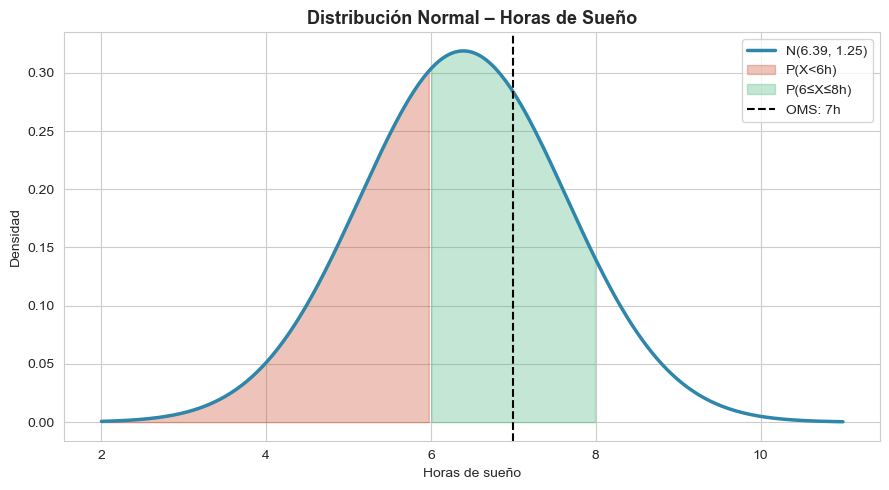

In [5]:
# ── Distribución Normal: horas de sueño ─────────────────────────────────────
from scipy.stats import norm
mu_s  = df['horas_sueno'].mean()
sig_s = df['horas_sueno'].std()
print(f'μ = {mu_s:.4f}  |  σ = {sig_s:.4f}')

# Probabilidades
p_menos6 = norm.cdf(6, mu_s, sig_s)
p_entre6_8 = norm.cdf(8, mu_s, sig_s) - norm.cdf(6, mu_s, sig_s)
p_mas8   = 1 - norm.cdf(8, mu_s, sig_s)
print(f'P(X < 6h)       = {p_menos6:.4f}')
print(f'P(6h ≤ X ≤ 8h)  = {p_entre6_8:.4f}')
print(f'P(X > 8h)       = {p_mas8:.4f}')

# Gráfico
fig, ax = plt.subplots(figsize=(9,5))
x = np.linspace(2, 11, 300)
ax.plot(x, norm.pdf(x, mu_s, sig_s), color='#2E86AB', lw=2.5, label=f'N({mu_s:.2f}, {sig_s:.2f})')
ax.fill_between(x, norm.pdf(x, mu_s, sig_s), where=(x<6), alpha=0.3, color='#C73E1D', label='P(X<6h)')
ax.fill_between(x, norm.pdf(x, mu_s, sig_s), where=((x>=6)&(x<=8)), alpha=0.3, color='#3BB273', label='P(6≤X≤8h)')
ax.axvline(7, color='black', lw=1.5, linestyle='--', label='OMS: 7h')
ax.set_title('Distribución Normal – Horas de Sueño', fontsize=13, fontweight='bold')
ax.set_xlabel('Horas de sueño'); ax.set_ylabel('Densidad')
ax.legend(); plt.tight_layout(); plt.show()

p(consume FV) = 0.6467  →  Binomial(n=10, p=0.65)
  P(X= 0) = 0.0000
  P(X= 1) = 0.0006
  P(X= 2) = 0.0046
  P(X= 3) = 0.0223
  P(X= 4) = 0.0715
  P(X= 5) = 0.1569
  P(X= 6) = 0.2394
  P(X= 7) = 0.2503
  P(X= 8) = 0.1718
  P(X= 9) = 0.0699
  P(X=10) = 0.0128


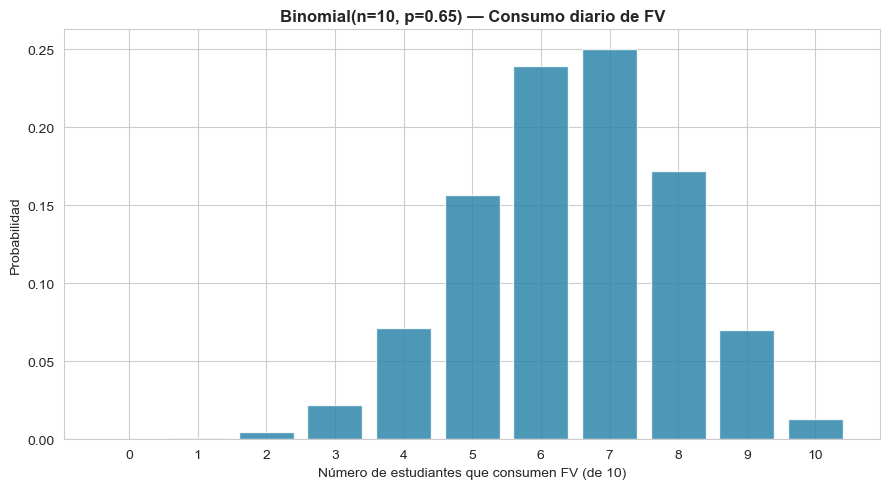

In [6]:
# ── Distribución Binomial: consumo de frutas/verduras ───────────────────────
from scipy.stats import binom
p_fv = df['consume_fv'].mean()
k = np.arange(0, 11)
pmf = binom.pmf(k, 10, p_fv)
print(f'p(consume FV) = {p_fv:.4f}  →  Binomial(n=10, p={p_fv:.2f})')
for ki, pi in zip(k, pmf):
    print(f'  P(X={ki:2d}) = {pi:.4f}')

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(k, pmf, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.set_title(f'Binomial(n=10, p={p_fv:.2f}) — Consumo diario de FV', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de estudiantes que consumen FV (de 10)')
ax.set_ylabel('Probabilidad'); ax.set_xticks(k)
plt.tight_layout(); plt.show()

λ (comidas/día) = 2.9733  →  Poisson(λ=2.97)
  P(X=0) = 0.0511
  P(X=1) = 0.1520
  P(X=2) = 0.2260
  P(X=3) = 0.2240
  P(X=4) = 0.1665
  P(X=5) = 0.0990
  P(X=6) = 0.0491
  P(X=7) = 0.0208
  P(X=8) = 0.0077


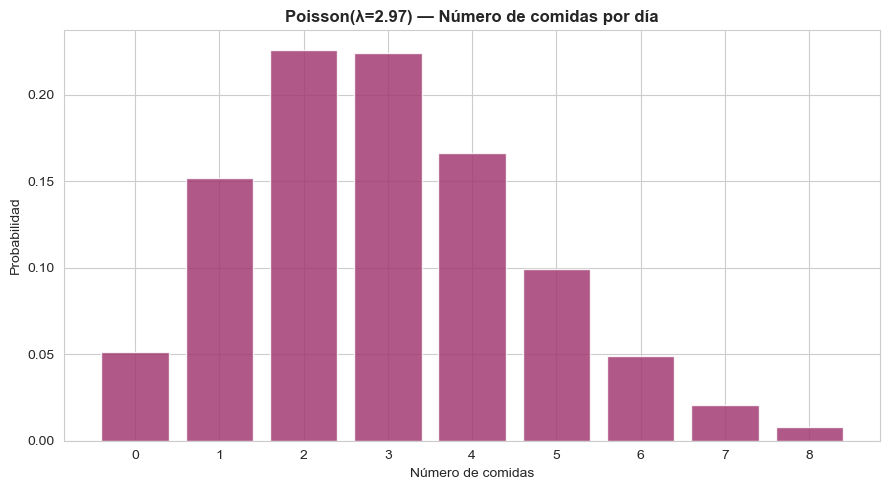

In [7]:
# ── Distribución Poisson: comidas por día ────────────────────────────────────
from scipy.stats import poisson
lam = df['comidas_dia'].mean()
k2  = np.arange(0, 9)
pmf2 = poisson.pmf(k2, lam)
print(f'λ (comidas/día) = {lam:.4f}  →  Poisson(λ={lam:.2f})')
for ki, pi in zip(k2, pmf2):
    print(f'  P(X={ki}) = {pi:.4f}')

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(k2, pmf2, color='#A23B72', edgecolor='white', alpha=0.85)
ax.set_title(f'Poisson(λ={lam:.2f}) — Número de comidas por día', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de comidas'); ax.set_ylabel('Probabilidad')
ax.set_xticks(k2); plt.tight_layout(); plt.show()

---
## 🔄 Lección 4 — Distribución Muestral y Teorema del Límite Central
El TLC establece que, para muestras suficientemente grandes (n ≥ 30), la distribución muestral de la media se aproxima a una normal, independientemente de la distribución poblacional.
$$\bar{X} \sim N\left(\mu,\; \frac{\sigma}{\sqrt{n}}\right)$$


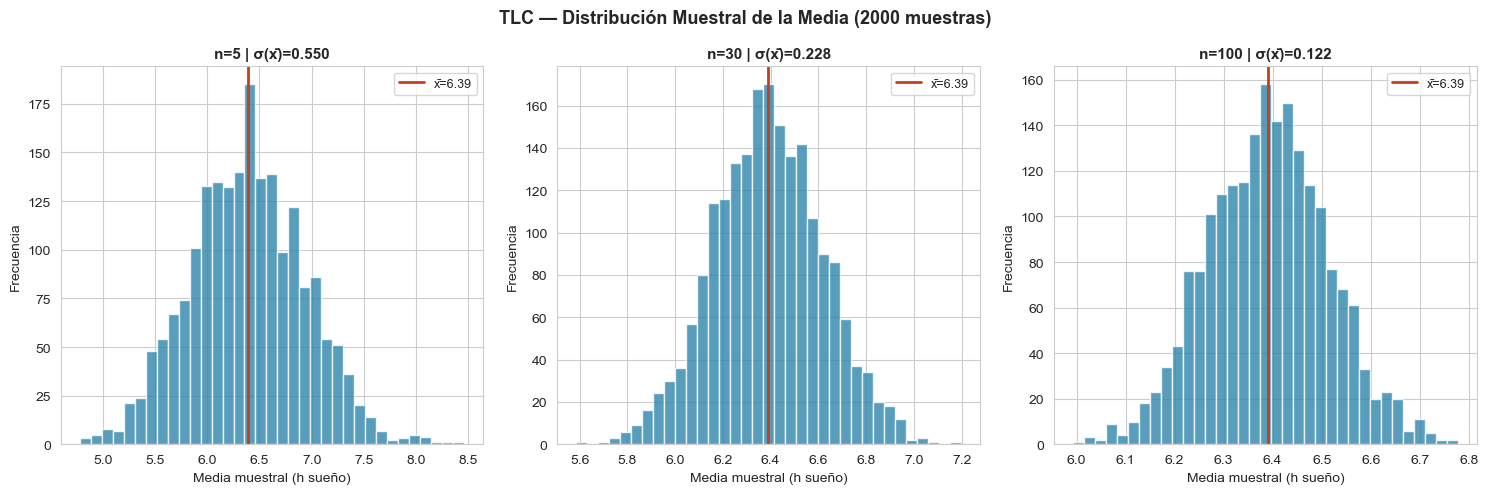

n   | σ_teórica  | σ_empírica
------------------------------------
5    | 0.5596     | 0.5587
10   | 0.3957     | 0.3958
30   | 0.2284     | 0.2245
50   | 0.1770     | 0.1779
100  | 0.1251     | 0.1263
150  | 0.1022     | 0.1015


In [8]:
# ── Verificación empírica del TLC ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
tamanios = [5, 30, 100]
for ax, tam in zip(axes, tamanios):
    medias = [df['horas_sueno'].sample(tam, replace=True).mean() for _ in range(2000)]
    ax.hist(medias, bins=35, color='#2E86AB', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(medias), color='#C73E1D', lw=2, label=f'x̄={np.mean(medias):.2f}')
    ax.set_title(f'n={tam} | σ(x̄)={np.std(medias):.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Media muestral (h sueño)'); ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
fig.suptitle('TLC — Distribución Muestral de la Media (2000 muestras)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Análisis del error estándar teórico vs empírico
print('n   | σ_teórica  | σ_empírica')
print('-'*36)
for tam in [5, 10, 30, 50, 100, 150]:
    medias = [df['horas_sueno'].sample(tam, replace=True).mean() for _ in range(2000)]
    se_teo = df['horas_sueno'].std() / np.sqrt(tam)
    se_emp = np.std(medias)
    print(f'{tam:<4} | {se_teo:.4f}     | {se_emp:.4f}')


---
## 🎯 Lección 5 — Inferencia e Intervalos de Confianza
La fórmula del intervalo de confianza para la media con σ desconocida es:
$$IC = \bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}$$


In [9]:
# ── IC para horas de sueño ───────────────────────────────────────────────────
from scipy.stats import t as t_dist

def intervalo_confianza(datos, conf):
    m = datos.mean(); s = datos.std(); nv = len(datos)
    t_val = t_dist.ppf((1+conf)/2, df=nv-1)
    me = t_val * s / np.sqrt(nv)
    return m-me, m+me, me

print('=== Horas de Sueño ===')
for conf in [0.90, 0.95, 0.99]:
    lo, hi, me = intervalo_confianza(df['horas_sueno'], conf)
    print(f'IC {int(conf*100)}%: [{lo:.4f} ; {hi:.4f}]  (±{me:.4f})')

print('\n=== IMC ===')
for conf in [0.90, 0.95, 0.99]:
    lo, hi, me = intervalo_confianza(df['imc'], conf)
    print(f'IC {int(conf*100)}%: [{lo:.4f} ; {hi:.4f}]  (±{me:.4f})')

print('\n=== Horas de Ejercicio ===')
for conf in [0.90, 0.95, 0.99]:
    lo, hi, me = intervalo_confianza(df['horas_ejercicio'], conf)
    print(f'IC {int(conf*100)}%: [{lo:.4f} ; {hi:.4f}]  (±{me:.4f})')


=== Horas de Sueño ===
IC 90%: [6.2229 ; 6.5611]  (±0.1691)
IC 95%: [6.1901 ; 6.5939]  (±0.2019)
IC 99%: [6.1254 ; 6.6586]  (±0.2666)

=== IMC ===
IC 90%: [22.4088 ; 23.4112]  (±0.5012)
IC 95%: [22.3116 ; 23.5084]  (±0.5984)
IC 99%: [22.1199 ; 23.7001]  (±0.7901)

=== Horas de Ejercicio ===
IC 90%: [1.6393 ; 2.0887]  (±0.2247)
IC 95%: [1.5957 ; 2.1323]  (±0.2683)
IC 99%: [1.5098 ; 2.2182]  (±0.3542)


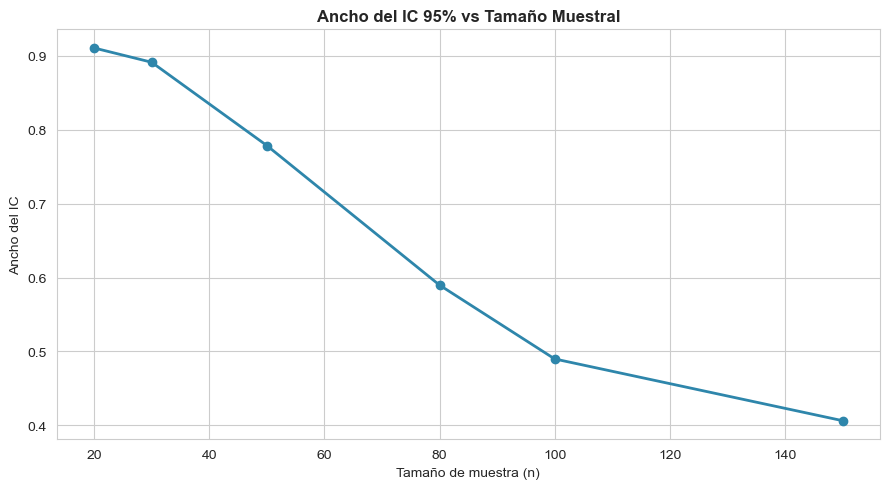

A mayor n → menor ancho → mayor precisión en la estimación.


In [10]:
# ── Efecto del tamaño muestral sobre el ancho del IC ────────────────────────
tamanios_ic = [20, 30, 50, 80, 100, 150]
anchos = []
for tam in tamanios_ic:
    muestra = df['horas_sueno'].sample(tam, replace=True)
    lo, hi, _ = intervalo_confianza(muestra, 0.95)
    anchos.append(hi - lo)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(tamanios_ic, anchos, marker='o', color='#2E86AB', lw=2)
ax.set_title('Ancho del IC 95% vs Tamaño Muestral', fontsize=12, fontweight='bold')
ax.set_xlabel('Tamaño de muestra (n)'); ax.set_ylabel('Ancho del IC')
plt.tight_layout(); plt.show()
print('A mayor n → menor ancho → mayor precisión en la estimación.')

---
## ✅ Lección 6 — Test de Significancia
### Test 1: Media de horas de sueño vs 7 h recomendadas
- **H₀**: μ = 7 h  
- **H₁**: μ ≠ 7 h  
- **Prueba**: t de Student para una muestra  
- **α** = 0.05

### Test 2: Proporción de estudiantes que practican deporte
- **H₀**: p = 0.50  
- **H₁**: p ≠ 0.50  
- **Prueba**: Z para proporción  
- **α** = 0.05


In [11]:
# ── Test 1: t de Student ─────────────────────────────────────────────────────
from scipy import stats

t_obs, p_valor = stats.ttest_1samp(df['horas_sueno'], 7)
gl = len(df) - 1
t_crit = stats.t.ppf(0.975, df=gl)
alpha = 0.05

print('=== TEST t — Horas de Sueño vs 7 h ===')
print(f'n          = {len(df)}')
print(f'Media obs. = {df["horas_sueno"].mean():.4f}')
print(f't_obs      = {t_obs:.4f}')
print(f't_crítico  = ±{t_crit:.4f}')
print(f'p-valor    = {p_valor:.4f}')
print(f'Decisión   : {"RECHAZAR H₀" if p_valor < alpha else "NO rechazar H₀"} (α={alpha})')
print()
if p_valor < alpha:
    print('→ Existe evidencia estadística de que la media de sueño DIFIERE de 7 h.')
else:
    print('→ No existe evidencia suficiente para rechazar que la media sea 7 h.')


=== TEST t — Horas de Sueño vs 7 h ===
n          = 150
Media obs. = 6.3920
t_obs      = -5.9513
t_crítico  = ±1.9760
p-valor    = 0.0000
Decisión   : RECHAZAR H₀ (α=0.05)

→ Existe evidencia estadística de que la media de sueño DIFIERE de 7 h.


In [12]:
# ── Test 2: Z para proporción ────────────────────────────────────────────────
p0 = 0.50
p_hat = df['practica_deporte'].mean()
n_obs = len(df)
z_obs = (p_hat - p0) / np.sqrt(p0*(1-p0)/n_obs)
p_val2 = 2 * (1 - stats.norm.cdf(abs(z_obs)))
z_crit = 1.96

print('=== TEST Z — Proporción que practica deporte vs p₀=0.50 ===')
print(f'p̂  = {p_hat:.4f}')
print(f'z_obs    = {z_obs:.4f}')
print(f'z_crítico = ±{z_crit}')
print(f'p-valor  = {p_val2:.4f}')
print(f'Decisión : {"RECHAZAR H₀" if p_val2 < 0.05 else "NO rechazar H₀"} (α=0.05)')


=== TEST Z — Proporción que practica deporte vs p₀=0.50 ===
p̂  = 0.6867
z_obs    = 4.5724
z_crítico = ±1.96
p-valor  = 0.0000
Decisión : RECHAZAR H₀ (α=0.05)


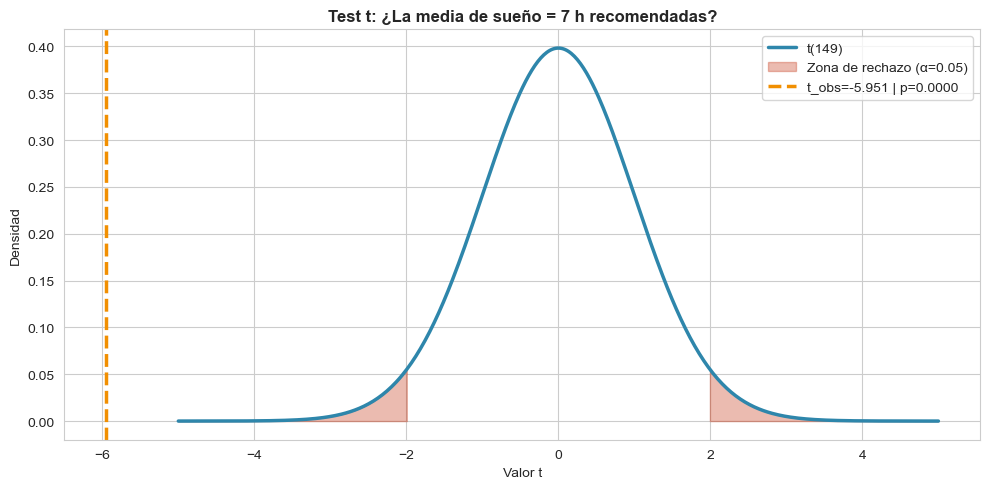

In [13]:
# ── Visualización del test t ─────────────────────────────────────────────────
x = np.linspace(-5, 5, 500)
y = stats.t.pdf(x, df=gl)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color='#2E86AB', lw=2.5, label=f't({gl})')
ax.fill_between(x, y, where=(x <= -t_crit), color='#C73E1D', alpha=0.35, label='Zona de rechazo (α=0.05)')
ax.fill_between(x, y, where=(x >= t_crit), color='#C73E1D', alpha=0.35)
ax.axvline(t_obs, color='#F18F01', lw=2.5, linestyle='--',
           label=f't_obs={t_obs:.3f} | p={p_valor:.4f}')
ax.set_title('Test t: ¿La media de sueño = 7 h recomendadas?', fontsize=12, fontweight='bold')
ax.set_xlabel('Valor t'); ax.set_ylabel('Densidad'); ax.legend()
plt.tight_layout(); plt.show()


---
## 🧠 Errores Tipo I y Tipo II
| Error | Definición | En este estudio |
|---|---|---|
| **Tipo I (α)** | Rechazar H₀ cuando es verdadera | Concluir que los estudiantes no duermen 7h cuando sí lo hacen |
| **Tipo II (β)** | No rechazar H₀ cuando es falsa | Concluir que duermen 7h cuando en realidad no lo hacen |

**Nivel α = 0.05** implica que aceptamos un 5% de probabilidad de cometer error Tipo I.


---
## 📝 Conclusiones Finales
1. **Sueño**: La media muestral de horas de sueño es **6.39 h**, inferior a las 7 h recomendadas. El test t confirma que esta diferencia es estadísticamente significativa.
2. **Ejercicio**: La media de actividad física es **1.86 h/semana**, con una distribución fuertemente asimétrica positiva (muchos estudiantes hacen poco o ningún ejercicio).
3. **IMC**: El IMC promedio de **22.91** se ubica dentro del rango normal, aunque con dispersión importante (σ = 3.71).
4. **TLC verificado**: Al incrementar el tamaño muestral, la distribución de medias muestrales converge visualmente a una normal, confirmando el Teorema del Límite Central.
5. **Recomendaciones**: Implementar programas de concientización sobre higiene del sueño y actividad física mínima semanal, priorizando estudiantes de años superiores con mayor carga académica.
